In [1]:
import pandas as pd 
import numpy as np
import warnings
warnings.filterwarnings("ignore")
import deepchem as dc
from sklearn.utils.class_weight import compute_sample_weight

# generate fingerprints from smiles
FP_radius, FP_size = 2, 1024
smiles_col = 'OriginalSmiles'
target = 'pKa'

tasks = [target]
loader = dc.data.CSVLoader(tasks=tasks, feature_field=smiles_col, 
                           featurizer=dc.feat.ConvMolFeaturizer())
dataset = loader.create_dataset("./dw_data/Opt1_acidic_tr.csv", shard_size=8192)

#y_bins = dataset.y
#y_bins = KBinsDiscretizer(n_bins=10, encode='ordinal', strategy='uniform').fit_transform(y_bins)
#weights = compute_sample_weight(class_weight="balanced", y=y_bins)
#dataset = dc.data.NumpyDataset(X=dataset.X, y=dataset.y, w=weights)

#y_bins = dataset.y[:,0]
#X = dataset.X
#X = X[y_bins < 8]
#y_bins = y_bins[y_bins < 8]
#X = X[y_bins > 2]
#y_bins = y_bins[y_bins > 2]
#dataset = dc.data.NumpyDataset(X=X, y=y_bins.reshape(-1,1))

splitter = dc.splits.RandomSplitter()
train_dataset, test_dataset = splitter.train_test_split(dataset, frac_train=0.8)
k_datasets = splitter.k_fold_split(dataset, k=5)

Skipped loading some PyTorch models, missing a dependency. No module named 'sympy'
No module named 'sympy'
Skipped loading modules with pytorch-geometric dependency, missing a dependency. No module named 'sympy'
Skipped loading modules with pytorch-lightning dependency, missing a dependency. No module named 'lightning'
Skipped loading some Jax models, missing a dependency. No module named 'jax'


<AxesSubplot: ylabel='Count'>

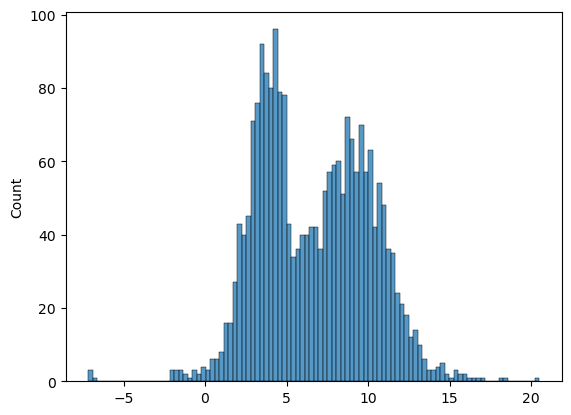

In [2]:
import seaborn as sns

sns.histplot(dataset.y[:,0], bins=100)

In [3]:
from sklearn.metrics import r2_score

import warnings
warnings.filterwarnings("ignore")

tasks = [target]
n_tasks = len(tasks)
metric = dc.metrics.Metric(dc.metrics.r2_score)

data = []
for i in range(5):
    train_dataset, test_dataset = k_datasets[i]
    num_features = train_dataset.X[0].get_atom_features().shape[1]
    model = dc.models.GraphConvModel(n_tasks, 
                                     mode='regression',
                                     number_atom_features=num_features,
                                     graph_conv_layers=[16, 16],
                                     dense_layer_size=8)
    
    model.fit(train_dataset, nb_epoch=100)
    
    train_preds = model.predict(train_dataset)[:,0]
    y_train = train_dataset.y[:,0]
    
    test_preds = model.predict(test_dataset)[:,0]
    y_test = test_dataset.y[:,0]
    
    train_r2 = r2_score(y_train, train_preds)
    test_r2 = r2_score(y_test, test_preds)
    
    data.append((i, train_r2, test_r2))
    
res_df = pd.DataFrame(data=data, columns=['Fold', 
                                          'Train-r2', 'Test-r2'])

res_df

,Fold,Train-r2,Test-r2
0,0,0.813370,0.588301
1,1,0.770443,0.573657
2,2,0.823624,0.552911
3,3,0.788415,0.620880
4,4,0.834812,0.552640


0.5526398899816667

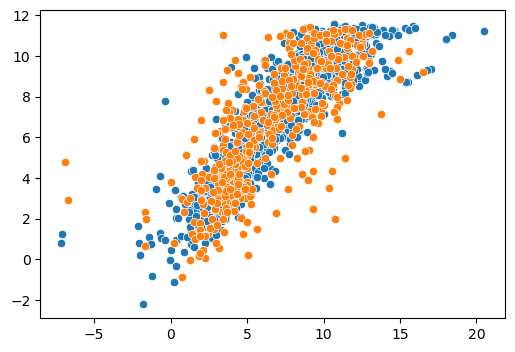

In [4]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6, 4))
sns.scatterplot(x=y_train, y=train_preds)
sns.scatterplot(x=y_test, y=test_preds)

r2_score(y_test, test_preds)